<h1><font color="#113D68" size=5>Actividad Semana 2</font></h1>



<h1><font color="#113D68" size=6>Resolución de un problema usando modelos pre-entrenados</font></h1>


<br><br>
<div style="text-align: right">
<font size=3>Daniel González</font><br>
<font size=3>Semana 2: Modelos Pre-entrenados</font><br>
<font size=3>IEBS</font>
</div>

---

In [2]:
import tensorflow as tf
import numpy as np
import pandas as pd

# Para mostrar gráficas
import matplotlib.pyplot as plt
%matplotlib inline

# Anaconda fixing problem
import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'

# Establecemos una semilla para numpy y tensorflow para poder reproducir la ejecución y los resultados
seed = 42
np.random.seed(seed)
tf.random.set_seed(seed)

En esta actividad vamos a seguir trabajando con modelo pre-entrenados para coger práctica y familiarizarnos con ellos. En especial vamos a familiarizarnos con la técnica de _fine-tuning_ vista en clase.

Este notebook será el inicio del caso práctico, por lo que el trabajo que realicéis en esta tarea os servirá para completar el caso práctico del módulo.

<a id="section2"></a>
# <font color="#004D7F" size=5>Flickr Style dataset</font>

Este dataset es el que hemos visto en la clase anterior y con el que trabajaremos en el caso práctico. Para refrescarlo, es un dataset que contiene imágenes en color donde queremos clasificar cada imagen según el estilo fotográfico al que pertenece.

El dataset de de imágenes Flickr Style tiene las siguintes características:
- Imágenes de 5 tipos de estilo: Detailed, Pastel, Melancholy, Noir y HDR.
- Imágenes en color, es decir, cada pixel tiene 3 valores entre 0 y 255, esos valores corresponden a los valores de RGB (Red, Green, Blue).
- Imágenes de diferentes tamaños, por lo que tendremos que redimensionarlas al mismo tamaño todas antes de usarlas en nuestro modelo.
- 2.000 imágenes en total para el entrenamiento y para el test.

#### **Imporante!!! Solo ejecutar esta celda una sola vez para descargar los datos, no ejecutarlas si ya tenéis los datos descargados**

In [3]:
!wget 'https://www.dropbox.com/s/ln92e9givhgzugr/flickr_style.zip?dl=0' -O flickr_style.zip
!unzip -q flickr_style.zip
!mkdir data
!mv flickr_style data/

"wget" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.
"unzip" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.
Ya existe el subdirectorio o el archivo data.
"mv" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.


Vamos a cargar los datos de las labels y los datos de las rutas de las imágenes:

In [4]:
# obtenemos el nombre de las primeras etiquetas seleccionadas
style_label_file = 'data/flickr_style/style_names.txt'

# Leemos el archivo de etiquetas y lo guardamos en una lista
with open(style_label_file, 'r') as file:
    style_labels = file.readlines()
style_labels = [label.strip() for label in style_labels]
style_labels

['Detailed', 'Pastel', 'Melancholy', 'Noir', 'HDR']

In [5]:
# cargamos los datos de train
train_frame = pd.read_csv('data/flickr_style/train.txt', sep=" ", header=None)
train_frame.columns = ['files','labels_idx']
train_frame['labels'] = train_frame['labels_idx'].map({i:j for i,j in enumerate(style_labels)})

train_frame.head()

,files,labels_idx,labels
0,data/flickr_style/images/2216312257_2ba4af8439...,3,Noir
1,data/flickr_style/images/1247783411_4b3332a10f...,3,Noir
2,data/flickr_style/images/12981126664_676c39228...,2,Melancholy
3,data/flickr_style/images/1184077873_911026e6ae...,3,Noir
4,data/flickr_style/images/8947602754_24140f40c5...,1,Pastel


In [6]:
# cargamos los datos de test
test_frame = pd.read_csv('data/flickr_style/test.txt', sep=" ", header=None)
test_frame.columns = ['files','labels_idx']
test_frame['labels'] = test_frame['labels_idx'].map({i:j for i,j in enumerate(style_labels)})

test_frame.head()

,files,labels_idx,labels
0,data/flickr_style/images/13059448154_d5ddf02da...,1,Pastel
1,data/flickr_style/images/13091035063_b32ef5213...,2,Melancholy
2,data/flickr_style/images/13230679494_88e5182c8...,4,HDR
3,data/flickr_style/images/12751269395_64f990535...,2,Melancholy
4,data/flickr_style/images/13285760404_05e737a5d...,2,Melancholy


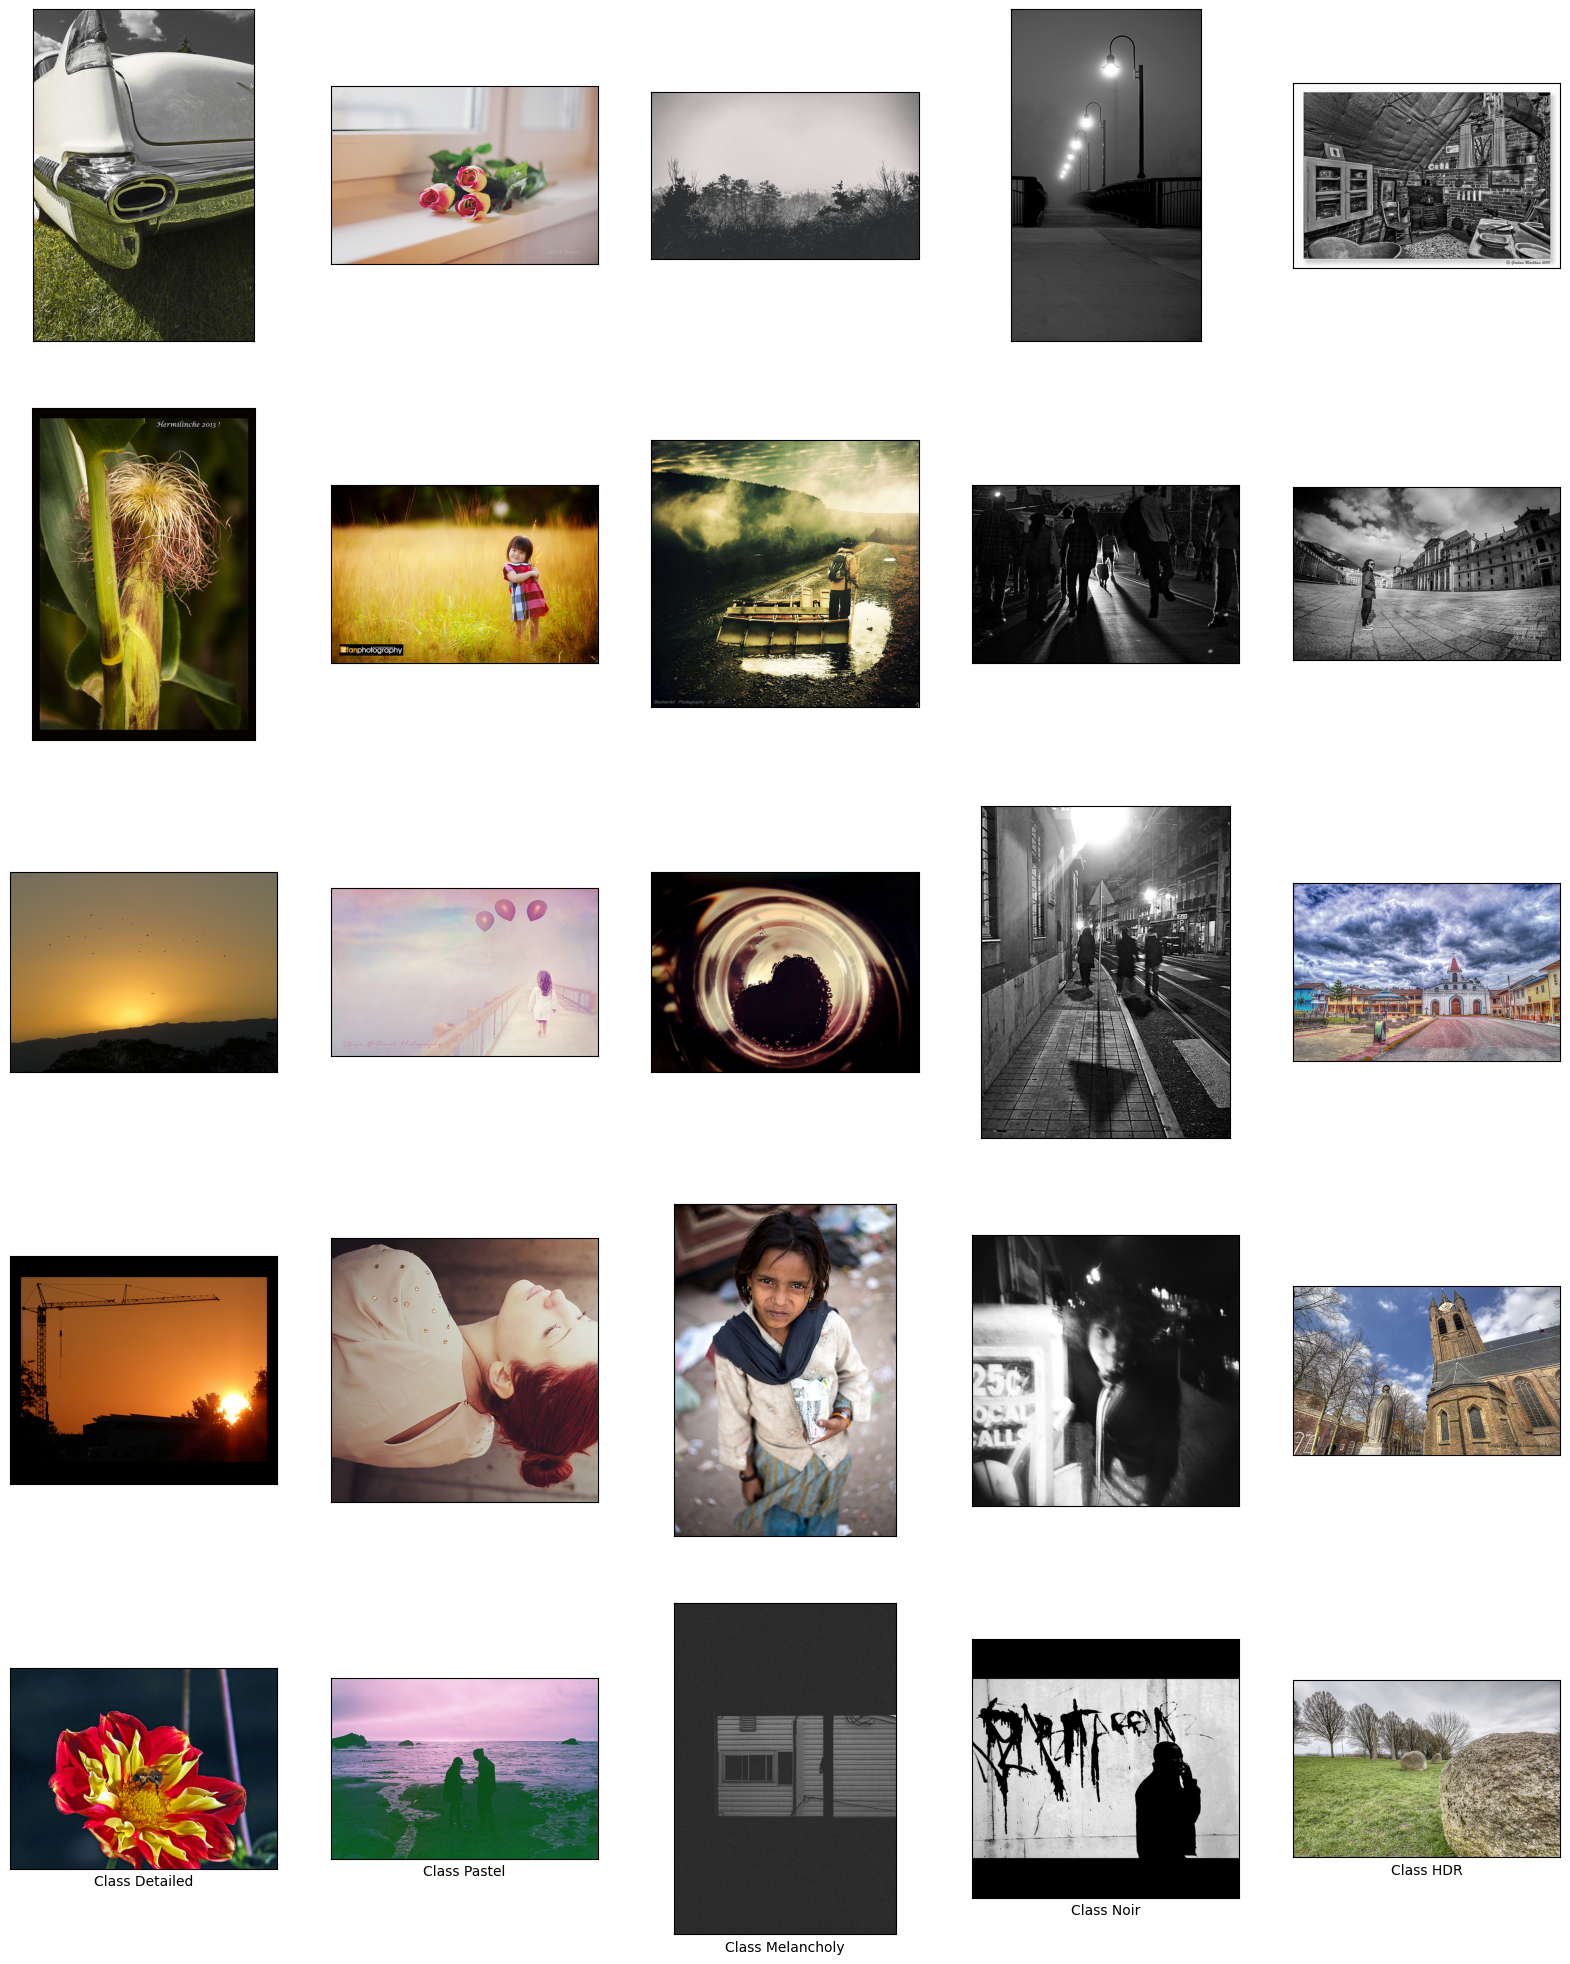

In [7]:
# Mostramos 5 imágenes de cada clase.
plot_n_images = 5
fig = plt.figure(figsize=(20, 25))

np.random.seed(1000)
for i in range(0,5):
    select_frame = train_frame[train_frame['labels_idx']==i]
    for j in range(0,plot_n_images):
        aux_index = np.random.choice(select_frame.index)
        fig_i=fig.add_subplot(plot_n_images,5,j*5+i+1)
        fig_i.imshow(plt.imread(train_frame['files'][aux_index]))
        
        fig_i.set_xticks(())
        fig_i.set_yticks(())
        
    fig_i.set_xlabel('Class %s' % style_labels[i])
    
plt.show()

## <font color="#004D7F" size=4>Ejercicio 1: preprocesamiento de las imágenes</font>
Como hemos visto en clase, para utilizar las imágenes usando un modelo pre-entrenado es necesario realizar una transformación sobre las imágenes que vamos a utilizar, es decir, tenemos que:

1. Cargar las imágenes
2. Redimensionarlas
3. Usar la función de `preprocess_input` del modelo pre-entrenado que vamos a utilizar.

En este problema vamos a utilizar otro modelo pre-entrado entre los que están disponibles en `tf.keras`, esta vez vamos a usar el modelo de _InceptionV3_, um modelo muy popular y usando frecuentemente. Podéis ver toda la información de este modelo [aquí](https://www.tensorflow.org/api_docs/python/tf/keras/applications/inception_v3/InceptionV3). Este modelo utilizar un tamaño de imagen de _**(299, 299, 3)**_, por lo que tendrás que usar este tamaño en el redimensionamiento.

Como hemos hecho en clase, define una función que se llame `load_img_inceptionv3(img_path)` a la cual le pasamos la ruta donde está alojada una imagen y le realiza todas las transformación necesarias para poder se utilizada luego en el proceso de entrenamiento.

In [8]:
def load_img_inceptionv3(img_path):
    img = tf.keras.utils.load_img(img_path,color_mode='rgb' ,target_size=(299,299,3)) #Cargamos la imagen y la redimensionamos a 299x299
    img = tf.keras.utils.img_to_array(img) # Covertimos la imagen a un array
    img = tf.keras.applications.inception_v3.preprocess_input(img) # Preprocesamos la imagen para la red InceptionV3
    
    return img

**Test**: Puedes probar esta función con el siguiente test, cuando la tengas definida ejecuta la siguiente celda y te debería dar como resultado:

```python
-0.5529412
```

In [9]:
img = load_img_inceptionv3('data/flickr_style/images/2216312257_2ba4af8439.jpg')
img[0,0,0]

-0.5529412

## <font color="#004D7F" size=4>Ejercicio 2: aplicar el preprocesamiento a todas las imágenes</font>
Una vez tenemos definida nuestra función de para transformar las imágenes, aplíca la transformación tanto al conjunto de train como al conjunto de test como hemos visto en clase.

In [10]:
# cargamos las imágenes de train
x_train = np.array([load_img_inceptionv3(file) for file in train_frame['files'].values])

# cargamos las imágenes de test
x_test = np.array([load_img_inceptionv3(file) for file in test_frame['files'].values])

# cargamos las clases de cada imagen
y_train = np.array(train_frame['labels_idx'].values)
y_test = np.array(test_frame['labels_idx'].values)

**Test**: Puedes probar si lo has hecho correctamente con el siguiente test, cuando hayas terminado ejecuta la siguiente celda y te debería dar como resultado:

```python
(array([-0.5529412, -0.5529412, -0.5372549], dtype=float32), 3)
```

In [11]:
x_train[0,0,0], y_train[0]

(array([-0.5529412, -0.5529412, -0.5372549], dtype=float32), 3)

## <font color="#004D7F" size=4>Ejercicio 3: cargar el modelo pre-entrenado InceptionV3</font>
Una vez tenemos los datos listos, vamos a cargar el modelo pre-entrenado de [_InceptionV3_](https://www.tensorflow.org/api_docs/python/tf/keras/applications/inception_v3/InceptionV3).

Como vamos a aplicar _fine-tuning_ recuerda usar los siguientes parámetros:
- `input_shape=(299, 299, 3)`
- `include_top=False`
- `pooling='avg'`

Además tienes que congelar todas las capas para que no se entrenen todas, recureda que solo queremos entrenar las últimas que añadamos nosotros.

In [12]:
# Cargamos el modelo preentrenado InceptionV3
base_model = tf.keras.applications.InceptionV3(input_shape=(299, 299, 3), include_top=False, weights='imagenet', pooling='avg')

# Congelamos las capas del modelo base
base_model.trainable = False

# Mostramos la arquitectura del modelo base
base_model.summary()

Model: "inception_v3"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 299, 299, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d (Conv2D)                (None, 149, 149, 32  864         ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 batch_normalization (BatchNorm  (None, 149, 149, 32  96         ['conv2d[0][0]']                 
 alization)                     )                                                      

**Test**: Puedes probar si lo has hecho correctamente con el siguiente test, cuando hayas terminado ejecuta la siguiente celda y te debería dar como resultado:

```python
[<keras.layers.merge.Concatenate at **************>,
 <keras.layers.pooling.GlobalAveragePooling2D at **************>]
```

In [13]:
base_model.layers[-2:]

## <font color="#004D7F" size=4>Ejercicio 4: añadir capas al modelo (_fine-tuning_)</font>
Una vez tenemos nuestro modelo base, vamos a añadir capas densas al final para entrenarlas y que el modelo se ajuste a nuestros datos.

Añade las siguientes capas al modelo base cargado:
- Capa Dropout con un valor de 0.60.
- Capa Densa de 128 neuronas y función de activación `relu`.
- Capa Dropout con un valor de 0.4.
- Capa Densa de salida con 5 neuronas y función de activación `softmax`.

In [14]:
# Añadimos las capas de salida al modelo base

model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.Dropout(0.6),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(5, activation='softmax')
])

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 inception_v3 (Functional)   (None, 2048)              21802784  
                                                                 
 dropout (Dropout)           (None, 2048)              0         
                                                                 
 dense (Dense)               (None, 128)               262272    
                                                                 
 dropout_1 (Dropout)         (None, 128)               0         
                                                                 
 dense_1 (Dense)             (None, 5)                 645       
                                                                 
Total params: 22,065,701
Trainable params: 262,917
Non-trainable params: 21,802,784
_________________________________________________________________


**Test**: Puedes probar si lo has hecho correctamente con el siguiente test, cuando hayas terminado ejecuta la siguiente celda y te debería dar como resultado:

```python
[<keras.layers.core.dropout.Dropout at **************>,
 <keras.layers.core.dense.Dense at **************>,
 <keras.layers.core.dropout.Dropout at **************>,
 <keras.layers.core.dense.Dense at **************>]
```

In [15]:
model.layers[-4:]

## <font color="#004D7F" size=4>Ejercicio 5: entrenar el modelo</font>
Una vez tenemos nuestro modelo listo para entrenar, vamos a configurar el entrenamiento y a entrenar nuesto modelo.

En el entrenamiento utiliza:
- Optimizador: Adam con learning rate de 0.001.
- Función de coste: `sparse_categorical_crossentropy`.
- Métricas: `accuracy`.
- Epochs: `25`
- validation_split: 0.2

In [ ]:
# Compilamos el modelo
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

# Entrenamos el modelo
history = model.fit(x_train, y_train, epochs=25, validation_split=0.2, batch_size=32, verbose=1)

Epoch 1/25
12/35 [=========>....................] - ETA: 24s - loss: 1.9566 - accuracy: 0.2188

## <font color="#004D7F" size=4>Ejercicio 6: evaluar el modelo</font>
Una vez entrenado el modelo usando _fine-tuning_ evalua el modelo usando el conjunto de test en la función `evaluate` y extráe conlcusiones de si el modelo tiene un buen rendimiento o no. Puedes visualizar como ha ido el entrenamiento usando una gráfica como hemos visto en clase.

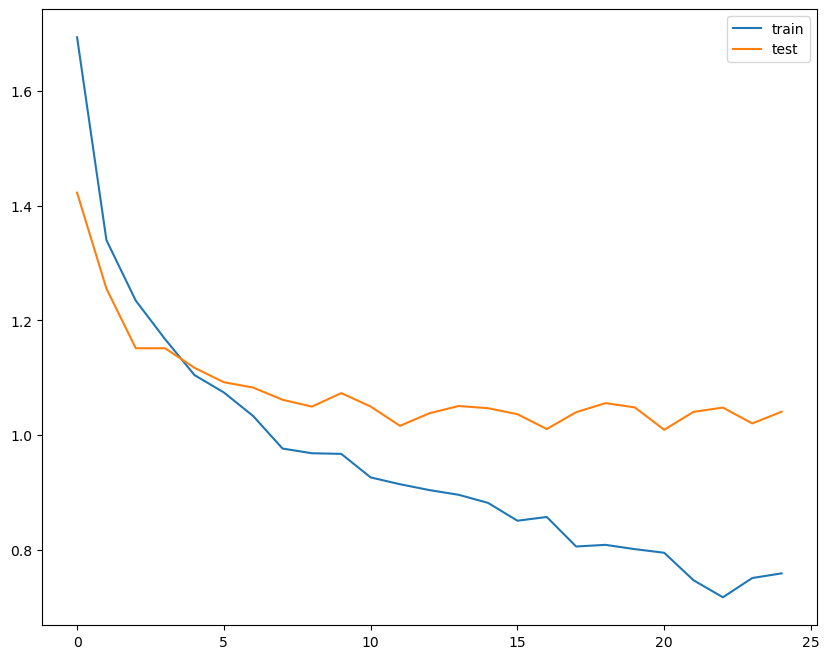

10/10 - 10s - loss: 1.1310 - accuracy: 0.5688 - 10s/epoch - 963ms/step
Test loss: 1.131044626235962
Test accuracy: 0.5687500238418579
10/10 [==============================] - 10s 1s/step


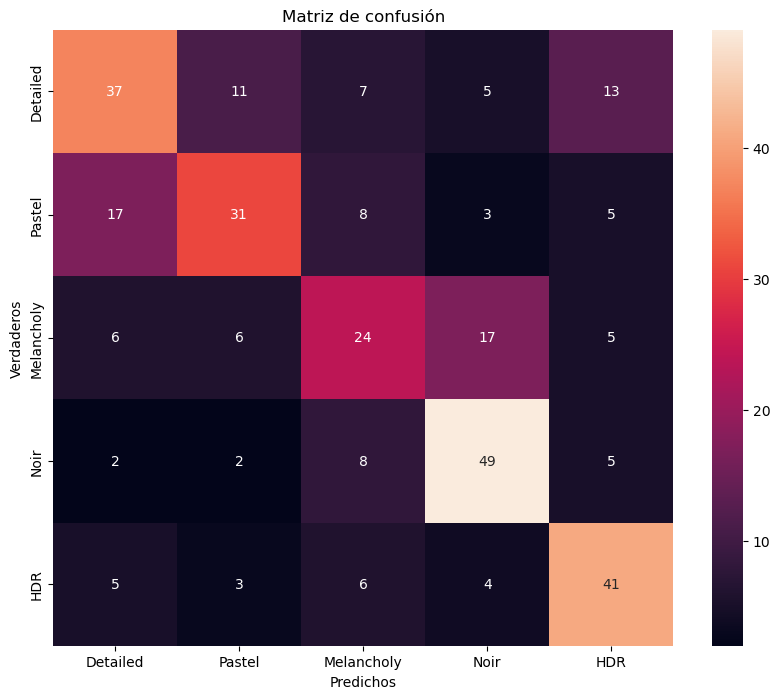

Accuracy para Detailed: 0.51
Accuracy para Pastel: 0.48
Accuracy para Melancholy: 0.41
Accuracy para Noir: 0.74
Accuracy para HDR: 0.69


In [38]:
# Graficamos la evolución de la función de pérdida y la precisión
plt.figure(figsize=(10, 8))
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

# Evaluamos el modelo en el conjunto de test
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print('Test loss:', test_loss)
print('Test accuracy:', test_acc)

# Matriz de confusión del modelo

#Importamos las librerías necesarias
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Predecimos las etiquetas de las imágenes de test
y_pred = model.predict(x_test)
y_pred = np.argmax(y_pred, axis=1)

# Creamos la matriz de confusión
CM = confusion_matrix(y_test, y_pred)

# Graficamos la matriz de confusión
plt.figure(figsize=(10, 8))
sns.heatmap(CM, annot=True, fmt='d', xticklabels=style_labels, yticklabels=style_labels)
plt.xlabel('Predichos')
plt.ylabel('Verdaderos')
plt.title('Matriz de confusión')
plt.show()

# Calculo de exactitud (Accuracy) por categoría
style_map = {i:j for i,j in enumerate(style_labels)}
def accuracy_by_category(y_true, y_pred):
    for i in style_map:
        true = y_true[y_true==i]
        pred = y_pred[y_true==i]
        acc = np.sum(true==pred)/len(true)
        print('Accuracy para %s: %.2f' % (style_map[i], acc))
        
accuracy_by_category(y_test, y_pred)
        

<h2>Conclusiones</h2>

Observando los resultados obtenidos, vemos que el modelo presenta una exactitud (accuracy) de 0.57 aproximadamente en promedio para la clasificación multiclase, lo cual podríamos considerar como un mal resultado. Si analizamos la capacidad del modelo de clasificar correctamente las imágenes para cada una de las categorías, vemos que el resultado mejora notablemente para las clases 'Noir' y 'HDR', mientras que vemos un resultado muy pobre para las clases 'Pastel' y especialmente para 'Melancoly'. Visto que la mayoría de las imágenes 'Melancoly' mal clasificadas se encuentran en la categoría 'Noir', podemos considerar que para la categoría 'Noir' el modelo presta especial atención a si la imagen está en blanco y negro o no, y aparentemente algunas de las imágenes del tipo 'Melancholy' lo están, cosa que se ve en las imágenes de ejemplo. Esto nos indica que el modelo no es capaz de distinguir entre 'Noir' y 'Melancholy' de manera precisa, por lo que el resultado general podemos entenderlo como pobre. Además, atendiendo a la evolución de la función de pérdida de la fase de valoración, podemos deducir que el modelo no podría mejorar siendo entrenado durante más épocas, dado que el descenso de la función de pérdida ya se ha estabilizado en esta fase.